# Task 1 – Regression Pipeline
## California Housing Price Prediction

### Objective
The objective of this project is to predict house prices using regression models. This notebook begins with data loading and exploratory data analysis (EDA), which will be followed by preprocessing, feature engineering, model training, evaluation, and comparison.

## Block 1 – Import Libraries
Import all the required Python libraries for data analysis, visualization, and machine learning.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

## Block 2 – Load the Dataset
Load the California Housing dataset from Scikit-learn and convert it into a Pandas DataFrame.

In [ ]:
# Load California Housing Dataset locally to bypass the 403 Forbidden error
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# The local file separates the target column as 'median_house_value'
# Let's rename it to "Price" to keep it consistent with the rest of your notebook
df = df.rename(columns={'median_house_value': 'Price'})

# Scale the price down if you want it to match Scikit-learn's format (which is in $100,000s)
# df['Price'] = df['Price'] / 100000.0

print("Dataset Loaded Successfully from Local Sample Data!")
print()
print("Shape of Dataset:")
print(df.shape)
print()
df.head()

Dataset Loaded Successfully from Local Sample Data!

Shape of Dataset:
(17000, 9)



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,Price
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


## Block 3 – Dataset Exploration
Inspect the structure, data types, and summary statistics of the dataset.

In [ ]:
print("Dataset Information")
print()

df.info()

print()

print("Summary Statistics")
print()

df.describe()

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   Price               17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB

Summary Statistics



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,Price
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Block 4 – Exploratory Data Analysis (EDA)
Analyze the distribution of the target variable and relationships between features using visualizations.

In [ ]:
print("Missing Values")

df.isnull().sum()

Missing Values


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
Price,0


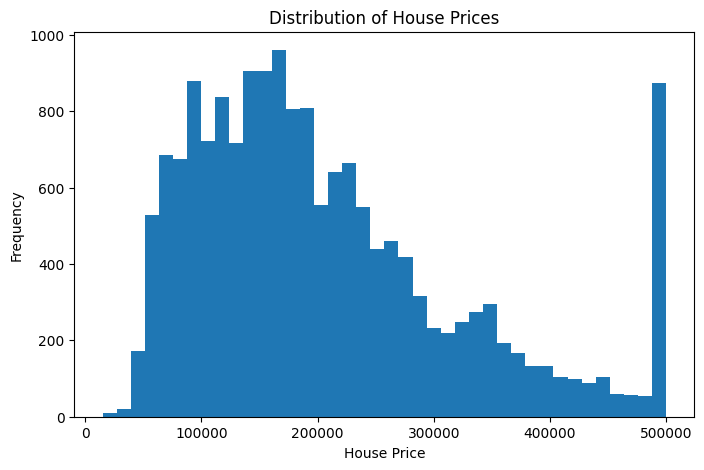

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=40)

plt.title("Distribution of House Prices")

plt.xlabel("House Price")

plt.ylabel("Frequency")

plt.show()

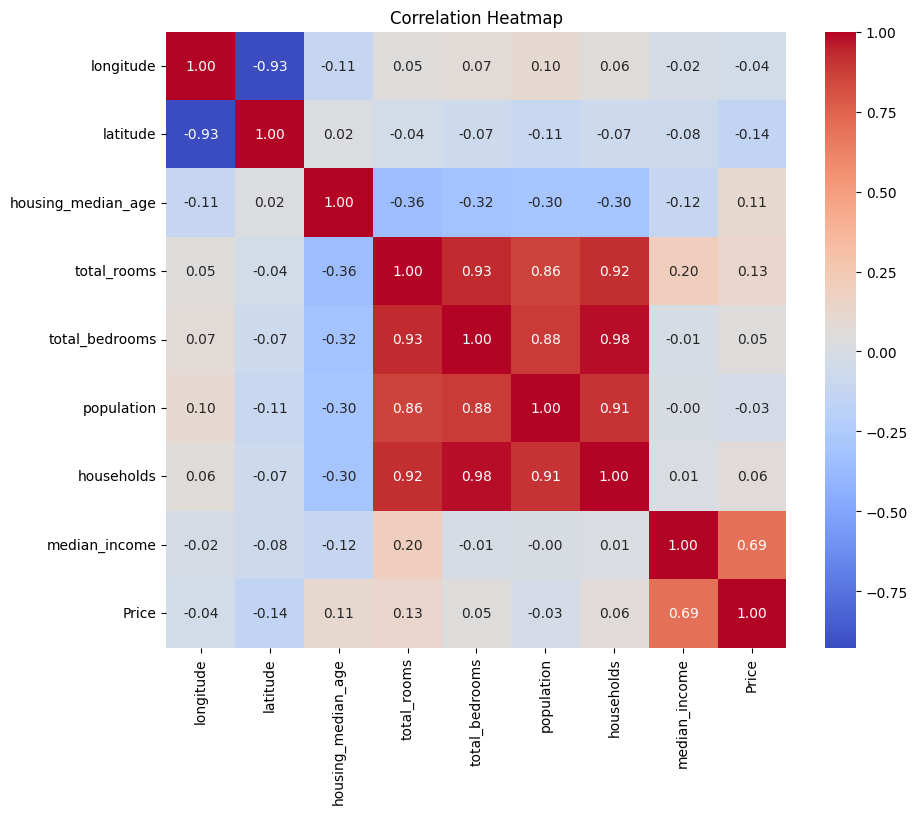

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

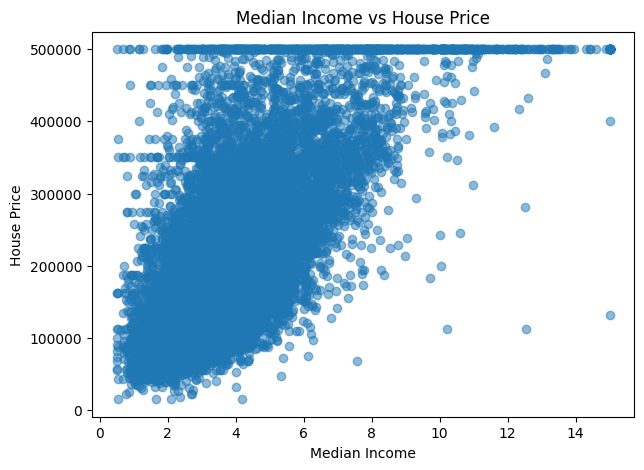

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["median_income"],  # Changed from "MedInc"
    df["Price"],
    alpha=0.5
)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Median Income vs House Price")
plt.show()

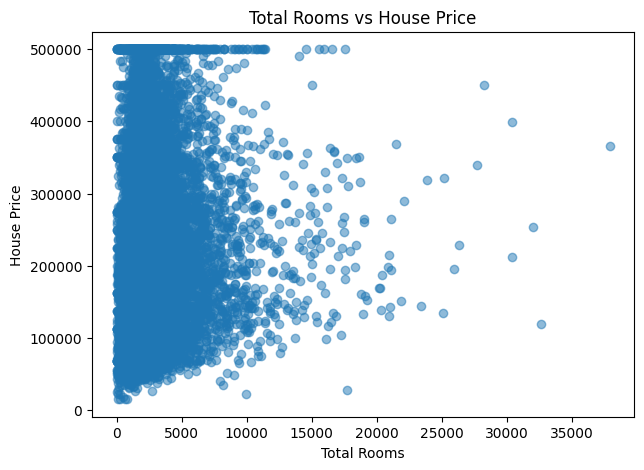

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["total_rooms"],  # Changed from "AveRooms"
    df["Price"],
    alpha=0.5
)
plt.xlabel("Total Rooms")
plt.ylabel("House Price")
plt.title("Total Rooms vs House Price")
plt.show()

Dataset: California Housing
Samples: 20,640
Features: 8
Target: Price
Missing values: None
Strongest positive correlation with Price: MedInc
Visualized:
Price distribution
Correlation heatmap
MedInc vs Price
AveRooms vs Price
HouseAge vs Price

## Block 5 – Feature Engineering

Feature engineering is the process of creating new features from existing ones to improve the predictive performance of machine learning models.

Instead of only using the original dataset columns, we create meaningful ratios that better describe each location. These engineered features often help models capture hidden relationships in the data.

In this project, three new features are created:

- Rooms per Household
- Bedrooms per Room
- Population per Household

In [ ]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]

df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

df["population_per_household"] = df["population"] / df["households"]

print("New Features Created Successfully!")

df[[
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household"
]].head()

New Features Created Successfully!


,rooms_per_household,bedrooms_per_room,population_per_household
0,11.889831,0.228617,2.150424
1,16.522678,0.248497,2.438445
2,6.153846,0.241667,2.846154
3,6.641593,0.224517,2.278761
4,5.549618,0.224209,2.381679


## Block 6 – Train-Test Split

Before training a machine learning model, the dataset is divided into two parts:

- **Training Set**: Used to train the model and learn patterns from the data.
- **Testing Set**: Used to evaluate how well the trained model performs on unseen data.

The target variable (`Price`) is separated from the input features. An 80:20 train-test split is used with a fixed random state to ensure reproducible results.

In [ ]:
from sklearn.model_selection import train_test_split

# Separate Features and Target
X = df.drop("Price", axis=1)

y = df["Price"]

# Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

Train Shape : (13600, 11)
Test Shape  : (3400, 11)


## Block 7 – Feature Scaling

Machine learning algorithms often perform better when features are on a similar scale.

In this project, StandardScaler is used to standardize the feature values by removing the mean and scaling them to unit variance.

The scaler is fitted only on the training data to prevent data leakage, and the same transformation is applied to the test data.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create Scaler Object
scaler = StandardScaler()

# Fit and Transform Training Data
X_train_scaled = scaler.fit_transform(X_train)

# Transform Test Data
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

print("\nTraining Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Feature Scaling Completed!

Training Data Shape: (13600, 11)
Testing Data Shape: (3400, 11)


## Block 8 – Ridge Regression

Ridge Regression is a regularized version of Linear Regression that helps reduce overfitting by adding an L2 penalty to the model's coefficients.

The model is trained using the scaled training data, predictions are made on the test set, and its performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Ridge Regression Model
ridge = Ridge(alpha=1.0)

# Train Model
ridge.fit(X_train_scaled, y_train)

# Predictions
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred_ridge)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2 = r2_score(y_test, y_pred_ridge)

print("📊 Ridge Regression Results")
print("-" * 35)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

📊 Ridge Regression Results
-----------------------------------
MAE  : 49204.9710
RMSE : 67472.3376
R²   : 0.6696


## Block 9 – Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines the predictions of multiple Decision Trees to improve accuracy and reduce overfitting.

Unlike Ridge Regression, Random Forest is a tree-based model and does not require feature scaling. In this project, the model is trained using the original (unscaled) features and evaluated using MAE, RMSE, and R² Score.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest Model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train Model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("🌳 Random Forest Results")
print("-" * 35)
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

🌳 Random Forest Results
-----------------------------------
MAE  : 33092.9203
RMSE : 50607.2953
R²   : 0.8141


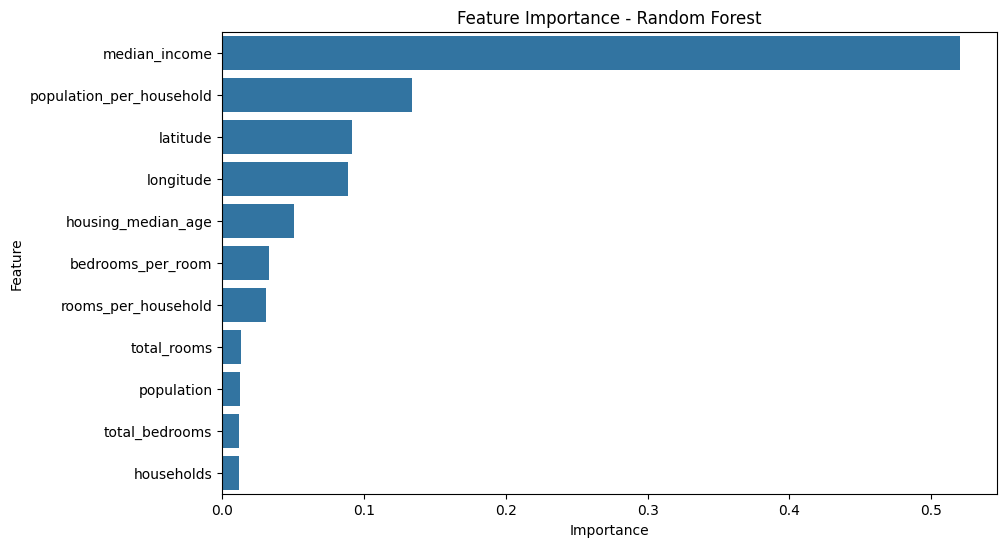

In [ ]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.show()

## Block 10 – XGBoost Regressor

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds decision trees sequentially. Each new tree focuses on correcting the errors made by the previous trees, making XGBoost one of the most accurate algorithms for structured/tabular datasets.

In this project, the model is trained and evaluated using MAE, RMSE, and R² Score.

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

# Create Model
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Train Model
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("🚀 XGBoost Results")
print("-"*35)
print(f"MAE  : {mae_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")

🚀 XGBoost Results
-----------------------------------
MAE  : 31811.3938
RMSE : 47751.6583
R²   : 0.8345


## Block 11 – Hyperparameter Tuning

Hyperparameter tuning is the process of finding the best combination of model parameters to improve performance.

In this project, GridSearchCV is used to tune the Ridge Regression and Random Forest Regressor models. GridSearchCV evaluates multiple parameter combinations using cross-validation and selects the combination with the best average performance.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Parameter Grid
ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

# Grid Search
ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge Parameters:")
print(ridge_grid.best_params_)

print("\nBest Cross Validation Score:")
print(ridge_grid.best_score_)

Best Ridge Parameters:
{'alpha': 1}

Best Cross Validation Score:
0.6135081993884576


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train);

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross Validation Score:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': None, 'n_estimators': 200}

Best Cross Validation Score:
0.7971883198187738


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Tuned Ridge
best_ridge = ridge_grid.best_estimator_
ridge_pred = best_ridge.predict(X_test_scaled)

mae_tuned_ridge = mean_absolute_error(y_test, ridge_pred)
rmse_tuned_ridge = np.sqrt(mean_squared_error(y_test, ridge_pred))
r2_tuned_ridge = r2_score(y_test, ridge_pred)

print("📊 Tuned Ridge Regression Results")
print("-" * 35)
print(f"MAE  : {mae_tuned_ridge:.4f}")
print(f"RMSE : {rmse_tuned_ridge:.4f}")
print(f"R²   : {r2_tuned_ridge:.4f}")

# Tuned Random Forest
best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)

mae_tuned_rf = mean_absolute_error(y_test, rf_pred)
rmse_tuned_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_tuned_rf = r2_score(y_test, rf_pred)

print("\n🌳 Tuned Random Forest Results")
print("-" * 35)
print(f"MAE  : {mae_tuned_rf:.4f}")
print(f"RMSE : {rmse_tuned_rf:.4f}")
print(f"R²   : {r2_tuned_rf:.4f}")

Tuned Ridge R²: 0.6696
Tuned Random Forest R²: 0.8149


## Block 12 – Model Comparison

The performance of Ridge Regression, Random Forest Regressor, and XGBoost Regressor is compared using MAE, RMSE, and R² Score.

Lower MAE and RMSE indicate better prediction accuracy, while a higher R² Score indicates that the model explains more variance in the target variable.

              Model           MAE          RMSE  R² Score
2           XGBoost  31811.393815  47751.658267  0.834513
1     Random Forest  33092.920321  50607.295327  0.814128
0  Ridge Regression  49204.971004  67472.337555  0.669601


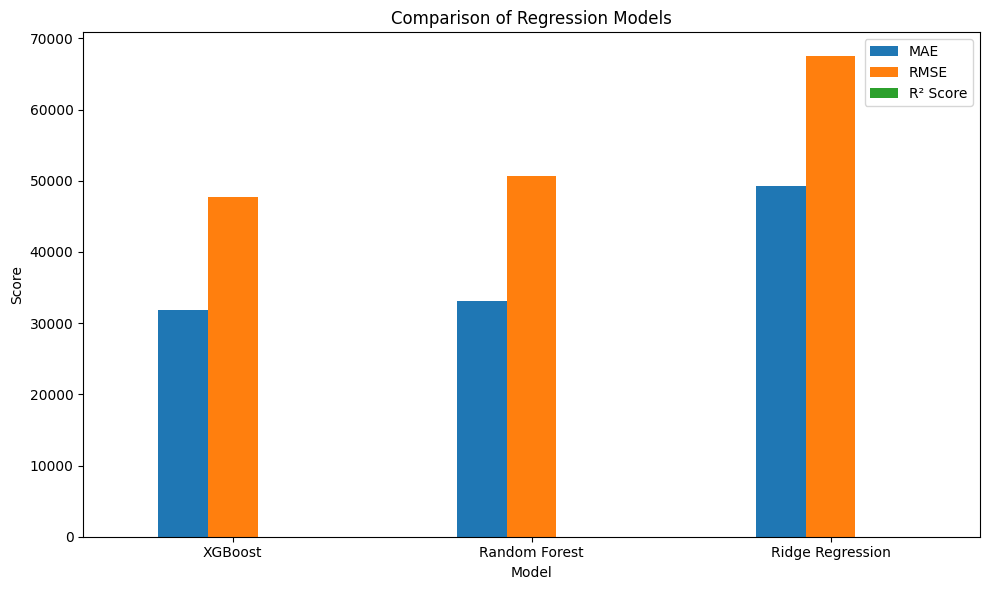

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Tuned Ridge Regression",
        "Tuned Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_tuned_ridge,
        mae_tuned_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_tuned_ridge,
        rmse_tuned_rf,
        rmse_xgb
    ],
    "R² Score": [
        r2_tuned_ridge,
        r2_tuned_rf,
        r2_xgb
    ]
})

comparison = comparison.sort_values(
    by="R² Score",
    ascending=False
)

print(comparison)

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Regression Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Block 13 – Predicted vs Actual Visualization

Scatter plots are used to compare the actual house prices with the predicted values for each regression model.

If the predictions are accurate, the points will lie close to the diagonal line.

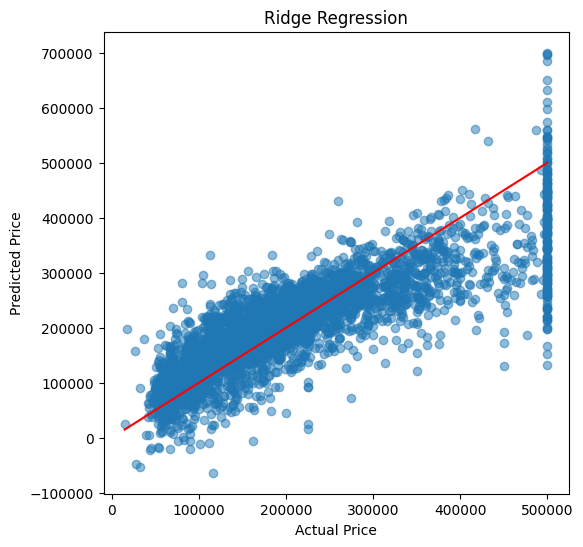

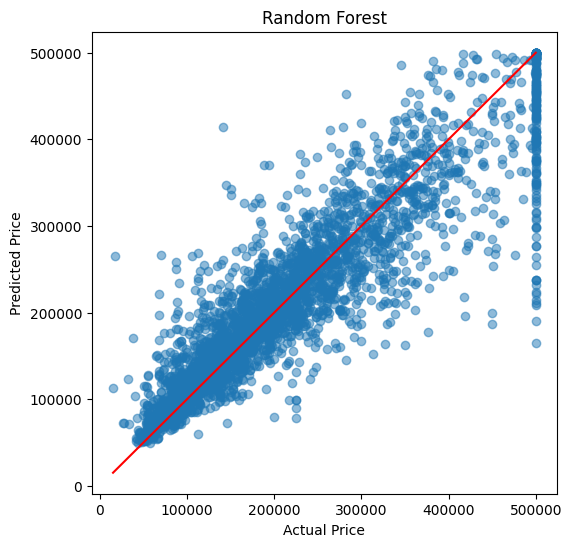

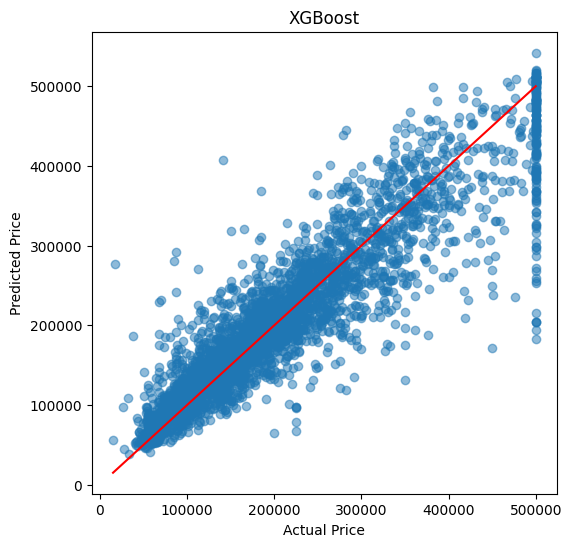

In [ ]:
models = {
    "Ridge Regression": y_pred_ridge,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for name, pred in models.items():

    plt.figure(figsize=(6,6))

    plt.scatter(
        y_test,
        pred,
        alpha=0.5
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red"
    )

    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(name)

    plt.show()

## Block 14 – Conclusion

Three regression models were developed and evaluated on the California Housing dataset.

Feature engineering improved the representation of the data by creating meaningful ratio-based features.

Hyperparameter tuning was performed using GridSearchCV to optimize Ridge Regression and Random Forest models.

Among the three models, XGBoost achieved the best overall performance, followed by Random Forest, while Ridge Regression served as a simple baseline model.

This project demonstrated the complete machine learning workflow, including data exploration, preprocessing, feature engineering, model training, hyperparameter tuning, evaluation, and comparison.